# Modélisation — benchmark

Six modèles, deux cibles, un protocole unique. L'objectif n'est pas de gagner
des points de R² : c'est de produire les chiffres qui justifient les décisions
du rapport.

**Protocole** — split 80/20 stratifié sur les déciles de la cible en log. Les
20 % de test sont mis de côté et ne servent qu'à l'évaluation finale et à la
vérification de couverture des intervalles. Les 80 % restants portent la
sélection (5-fold stratifié) et la conformalisation (hors fold, via
`CrossConformalRegressor`). Pas de jeu de conformalisation dédié : sur 1655
lignes, le cross-conformal est plus robuste et rend 20 % de données à
l'entraînement.

**Pourquoi stratifier** — la cible s'étend de 16 800 à 873 millions de kBtu. Un
fold qui capterait par hasard plusieurs tours du centre-ville aurait une RMSE
aberrante et fausserait le classement. Les bins servent au découpage uniquement,
jamais comme variable.

**Les modèles** — `DummyRegressor` comme référence R² = 0 ; RandomForest et
GradientBoosting comme baseline P3 rejouée dans le nouveau pipeline ;
`HistGradientBoosting` comme remplaçant moderne du GBR ; CatBoost et TabPFN comme
état de l'art. SVR et LinearRegression sont écartés : l'audit de P3 a déjà chiffré
leur infériorité (R² 0,23 et 0,36 contre 0,80), les rejouer reviendrait à
re-dériver un fait établi.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import features as F  # noqa: E402

RANDOM_STATE = 42
N_SPLITS = 5
N_BINS = 10
# Product decision, not a model parameter: 0.75 is where the interval becomes
# directly interpretable -- a factor of 2, "between half and double". See §8.
CONFIDENCE = 0.75

# TabPFN is licence-restricted (evaluation only) and CPU-bound: keep it switchable
RUN_TABPFN = True
TABPFN_N_ESTIMATORS = 4

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks")
pd.set_option("display.max_columns", 60)

mlflow.set_tracking_uri(f"sqlite:///{(ROOT / 'mlflow.db').as_posix()}")
mlflow.set_experiment("seattle-energy")
print("MLflow", mlflow.__version__, "->", mlflow.get_tracking_uri())

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/08/21 17:37:18 INFO mlflow.tracking.fluent: Experiment with name 'seattle-energy' does not exist. Creating a new experiment.


MLflow 3.15.1 -> sqlite:///c:/Users/Kevin/projects/OC_P13/mlflow.db


## 1. Données et split

Le chemin est exactement celui de l'entraînement en production : `from_benchmark`
convertit les consommations en booléens de présence et retire les colonnes brutes,
puis `build_features` produit la matrice. Aucune transformation ad hoc ici.

In [2]:
raw = pd.read_csv(ROOT / "data" / "dfclean.csv")
desc = F.from_benchmark(raw)

X = F.build_features(desc)
targets = {
    "energie": np.log1p(desc["SiteEnergyUse(kBtu)"]),
    "emissions": np.log1p(desc["TotalGHGEmissions"]),
}

# Stratification bins: splitting device only, never a feature
bins = pd.qcut(targets["energie"], N_BINS, labels=False, duplicates="drop")

idx_train, idx_test = train_test_split(
    X.index, test_size=0.2, stratify=bins, random_state=RANDOM_STATE
)
bins_train = bins.loc[idx_train]

print(f"{len(X)} bâtiments, {X.shape[1]} variables")
print(f"train {len(idx_train)}  |  test {len(idx_test)}")
print()
print("Contrôle de stratification — part de chaque décile :")
pd.DataFrame({
    "train": bins.loc[idx_train].value_counts(normalize=True).sort_index(),
    "test": bins.loc[idx_test].value_counts(normalize=True).sort_index(),
}).round(3).T

Dropped 1 building(s) with no usage breakdown: [496]
1655 bâtiments, 32 variables
train 1324  |  test 331

Contrôle de stratification — part de chaque décile :


SiteEnergyUse(kBtu),0,1,2,3,4,5,6,7,8,9
train,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.100,0.1,0.1
test,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.103,0.1,0.1


## 2. Métriques

L'entraînement se fait sur la cible en log, mais un agent de la Ville raisonne en
kBtu et en tonnes de CO2. Les métriques sont donc calculées des deux côtés.

**Attention au piège des métriques absolues.** La cible s'étend de 16 800 à
873 millions de kBtu : sur le jeu de test, **cinq bâtiments sur 331 portent 85 %
de la RMSE au carré**, et un seul en porte 76 %. `RMSE_unite` ne mesure donc pas
le modèle, elle mesure un bâtiment. La MAE est moins sensible mais reste
contaminée — sa moyenne vaut quatre fois sa médiane.

D'où les deux métriques robustes retenues, qui sont les mêmes que MAE et MAPE
mais prises à la médiane plutôt qu'à la moyenne :

- **`MedAE_unite`** — médiane des écarts absolus |réel − prédit|, en kBtu ou tCO2e
- **`MedAPE`** — médiane des écarts **relatifs** |réel − prédit| / réel, sans unité

Sur une distribution à queue lourde, la moyenne décrit un bâtiment qui n'existe
pas ; la médiane décrit celui que l'utilisateur a sous les yeux.

**Hiérarchie de lecture** : `R2_log` est la métrique technique, celle qui se
compare aux 0,80 de P3. **`MedAPE` est la métrique métier** — l'erreur relative
du bâtiment typique. `RMSE_unite` et `MAE_unite` sont conservées comme
diagnostic, jamais comme chiffre de communication.

In [3]:
def evaluate(y_true_log, y_pred_log):
    """Metrics in the log space the model works in, and in the business unit.

    Median-based metrics lead: on a target spanning five orders of magnitude,
    mean-based ones describe a building that does not exist.
    """
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    absolute = np.abs(y_true - y_pred)
    relative = absolute / y_true

    return {
        # Technical: comparable with the 0.80 reported by P3
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        # Business: robust to the handful of giant buildings
        "MedAPE": float(np.median(relative)),
        "MedAE_unite": float(np.median(absolute)),
        # Diagnostic only -- dominated by five buildings, never quote these alone
        "MAPE": float(np.mean(relative)),
        "RMSE_unite": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE_unite": mean_absolute_error(y_true, y_pred),
    }

## 3. Les modèles

Chaque modèle est une fabrique, pour qu'un modèle neuf soit instancié à chaque
fold et à chaque cible — aucun état ne fuit d'un run à l'autre.

In [4]:
def make_models():
    models = {
        "Dummy": lambda: DummyRegressor(strategy="mean"),
        "RandomForest": lambda: RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "GradientBoosting": lambda: GradientBoostingRegressor(random_state=RANDOM_STATE),
        "HistGradientBoosting": lambda: HistGradientBoostingRegressor(
            random_state=RANDOM_STATE
        ),
    }

    from catboost import CatBoostRegressor

    models["CatBoost"] = lambda: CatBoostRegressor(
        verbose=0, random_state=RANDOM_STATE, allow_writing_files=False
    )

    if RUN_TABPFN:
        from tabpfn import TabPFNRegressor

        models["TabPFN"] = lambda: TabPFNRegressor(
            n_estimators=TABPFN_N_ESTIMATORS, device="cpu", random_state=RANDOM_STATE
        )

    return models


MODELS = make_models()
print(f"{len(MODELS)} modèles : {', '.join(MODELS)}")

6 modèles : Dummy, RandomForest, GradientBoosting, HistGradientBoosting, CatBoost, TabPFN


## 4. Benchmark

Prédictions hors fold sur les 80 % d'entraînement, pour les six modèles et les
deux cibles. Chaque combinaison donne un run MLflow. `CodeCarbon` mesure
l'empreinte de la boucle — cohérence oblige sur un projet qui prédit des
émissions.

In [5]:
from codecarbon import EmissionsTracker


def benchmark(feature_matrix, label="features"):
    """Out-of-fold evaluation of every model on every target.

    Each model gets its own CodeCarbon task, so the carbon footprint becomes a
    comparison criterion alongside R2 -- not a single global footnote.
    """
    rows = []
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    folds = list(splitter.split(feature_matrix.loc[idx_train], bins_train))

    tracker = EmissionsTracker(
        project_name=f"seattle-{label}", output_dir=str(ROOT),
        log_level="error", save_to_file=True,
    )
    tracker.start()
    try:
        for target_name, y in targets.items():
            X_tr = feature_matrix.loc[idx_train]
            y_tr = y.loc[idx_train]

            for model_name, factory in MODELS.items():
                # The run wraps the training itself, so MLflow's own `duration`
                # is meaningful in the UI and not just the logging overhead
                with mlflow.start_run(run_name=f"{label}-{target_name}-{model_name}"):
                    mlflow.log_params({
                        "modele": model_name, "cible": target_name, "features": label,
                        "n_splits": N_SPLITS, "n_features": feature_matrix.shape[1],
                    })

                    tracker.start_task(f"{target_name}-{model_name}")
                    started = time.time()
                    oof = cross_val_predict(factory(), X_tr, y_tr, cv=folds, n_jobs=1)
                    elapsed = time.time() - started
                    task = tracker.stop_task()

                    scores = evaluate(y_tr, oof)
                    scores |= {
                        "modele": model_name, "cible": target_name, "features": label,
                        "secondes": elapsed,
                        "co2_g": task.emissions * 1000,
                        "kwh": task.energy_consumed,
                    }
                    rows.append(scores)
                    mlflow.log_metrics({k: v for k, v in scores.items()
                                        if isinstance(v, float)})

                print(f"  {label:12s} {target_name:10s} {model_name:20s} "
                      f"R2={scores['R2_log']:.4f}  {elapsed:5.1f}s  "
                      f"{scores['co2_g']:.3f} g CO2eq", flush=True)
    finally:
        tracker.stop()

    return pd.DataFrame(rows)


results = benchmark(X, label="booleens")
print()
print(f"Empreinte totale du benchmark : {results['co2_g'].sum():.2f} g CO2eq")

[codecarbon WARNING @ 17:37:20] Multiple instances of codecarbon are allowed to run at the same time.


  booleens     energie    Dummy                R2=-0.0001    0.0s  0.005 g CO2eq
  booleens     energie    RandomForest         R2=0.7251    1.4s  0.003 g CO2eq
  booleens     energie    GradientBoosting     R2=0.7447    0.5s  0.001 g CO2eq
  booleens     energie    HistGradientBoosting R2=0.7322    1.8s  0.003 g CO2eq
  booleens     energie    CatBoost             R2=0.7435    3.7s  0.009 g CO2eq


c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tab

  booleens     energie    TabPFN               R2=0.7643   38.1s  0.089 g CO2eq
  booleens     emissions  Dummy                R2=-0.0001    0.0s  0.000 g CO2eq
  booleens     emissions  RandomForest         R2=0.7072    1.2s  0.003 g CO2eq
  booleens     emissions  GradientBoosting     R2=0.7195    0.5s  0.001 g CO2eq
  booleens     emissions  HistGradientBoosting R2=0.7094    0.5s  0.001 g CO2eq
  booleens     emissions  CatBoost             R2=0.7234    3.5s  0.008 g CO2eq


c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tab

  booleens     emissions  TabPFN               R2=0.7445   36.1s  0.085 g CO2eq

Empreinte totale du benchmark : 0.21 g CO2eq


## 5. Comparatif

In [6]:
pivot = results.pivot(index="modele", columns="cible", values="R2_log")
pivot["moyenne"] = pivot.mean(axis=1)
pivot = pivot.sort_values("moyenne", ascending=False)
pivot.round(4)

cible,emissions,energie,moyenne
modele,,,
TabPFN,0.7445,0.7643,0.7544
CatBoost,0.7234,0.7435,0.7334
GradientBoosting,0.7195,0.7447,0.7321
HistGradientBoosting,0.7094,0.7322,0.7208
RandomForest,0.7072,0.7251,0.7162
Dummy,-0.0001,-0.0001,-0.0001


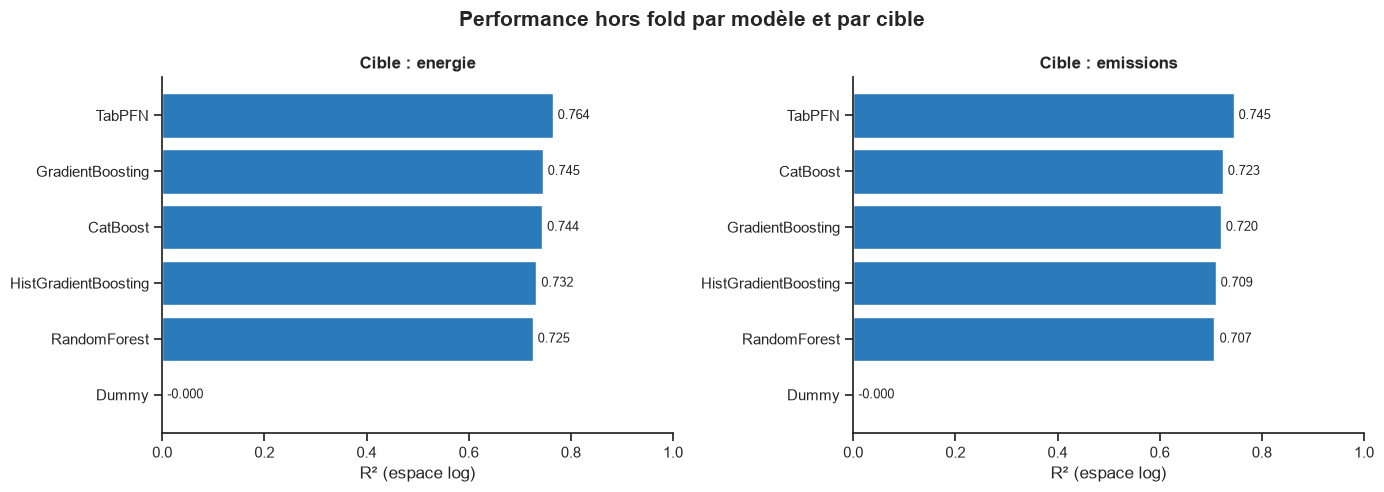

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cible in zip(axes, targets):
    subset = results[results["cible"] == cible].sort_values("R2_log")
    colours = ["#c0392b" if m == "Dummy" else "#2b7bba" for m in subset["modele"]]
    ax.barh(subset["modele"], subset["R2_log"], color=colours)
    ax.set_xlabel("R² (espace log)")
    ax.set_xlim(0, 1)
    ax.set_title(f"Cible : {cible}", fontweight="bold")
    for y_pos, value in enumerate(subset["R2_log"]):
        ax.text(max(value, 0) + 0.01, y_pos, f"{value:.3f}", va="center", fontsize=9)

fig.suptitle("Performance hors fold par modèle et par cible", fontsize=15, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
# Business metrics first, absolute ones kept as diagnostic
table = results.sort_values(["cible", "R2_log"], ascending=[True, False])[
    ["cible", "modele", "R2_log", "MedAPE", "MedAE_unite",
     "MAPE", "RMSE_unite", "secondes", "co2_g"]
].round(3).reset_index(drop=True)

# How much carbon each point of R2 above the Dummy costs
baseline = results[results["modele"] == "Dummy"].set_index("cible")["R2_log"]
table["g_CO2_par_point_R2"] = (
    table["co2_g"] / ((table["R2_log"] - table["cible"].map(baseline)) * 100)
).round(3)
table

,cible,modele,R2_log,MedAPE,MedAE_unite,MAPE,RMSE_unite,secondes,co2_g,g_CO2_par_point_R2
0,emissions,TabPFN,0.745,0.425,20.963,0.819,5.426510e+02,36.123,0.085,0.001
1,emissions,CatBoost,0.723,0.451,22.502,0.868,6.452380e+02,3.523,0.008,0.000
2,emissions,GradientBoosting,0.720,0.471,23.107,0.860,5.982050e+02,0.467,0.001,0.000
3,emissions,HistGradientBoosting,0.709,0.462,22.760,0.882,6.632270e+02,0.533,0.001,0.000
4,emissions,RandomForest,0.707,0.459,23.233,0.893,6.547750e+02,1.238,0.003,0.000
5,emissions,Dummy,-0.000,0.766,41.136,3.071,7.873850e+02,0.004,0.000,0.000
6,energie,TabPFN,0.764,0.326,863272.750,0.594,1.997439e+07,38.053,0.089,0.001
7,energie,GradientBoosting,0.745,0.366,922818.135,0.602,2.655192e+07,0.483,0.001,0.000
8,energie,CatBoost,0.744,0.362,933442.738,0.608,2.716432e+07,3.709,0.009,0.000
9,energie,HistGradientBoosting,0.732,0.374,949742.222,0.647,2.691856e+07,1.833,0.003,0.000


## 6. Le coût de la fuite — ratios contre booléens

C'est la pièce maîtresse de l'audit (écart E08). P3 utilisait `RatioElec`,
`RatioGaz` et `RatioSteam`, calculés depuis la consommation réelle — donc
indisponibles pour un bâtiment non relevé, qui est précisément le cas d'usage.
On les a remplacés par trois booléens de présence.

La question que le rapport doit trancher avec un chiffre : **combien coûte ce
remplacement ?** On rejoue le même protocole sur un jeu de features « façon P3 »,
et on compare.

In [9]:
# P3-style feature set: swap the three presence booleans for the leaking ratios.
# Built here only -- these features must never reach production.
energy = raw.set_index("OSEBuildingID").loc[desc["OSEBuildingID"]]
site_energy = energy["SiteEnergyUse(kBtu)"].to_numpy()

X_p3 = X.drop(columns=["HasElectricity", "HasGas", "HasSteam"]).copy()
X_p3["RatioElec"] = np.clip(energy["Electricity(kBtu)"].to_numpy() / site_energy, 0, 1)
X_p3["RatioGaz"] = np.clip(energy["NaturalGas(kBtu)"].to_numpy() / site_energy, 0, 1)
X_p3["RatioSteam"] = np.clip(energy["SteamUse(kBtu)"].to_numpy() / site_energy, 0, 1)
X_p3.index = X.index

print(f"jeu P3 : {X_p3.shape[1]} variables (contre {X.shape[1]} en production)")
results_p3 = benchmark(X_p3, label="ratios_P3")

jeu P3 : 32 variables (contre 32 en production)
  ratios_P3    energie    Dummy                R2=-0.0001    0.0s  0.004 g CO2eq
  ratios_P3    energie    RandomForest         R2=0.7372    1.2s  0.003 g CO2eq
  ratios_P3    energie    GradientBoosting     R2=0.7533    0.6s  0.001 g CO2eq
  ratios_P3    energie    HistGradientBoosting R2=0.7485    0.6s  0.001 g CO2eq
  ratios_P3    energie    CatBoost             R2=0.7562    3.7s  0.009 g CO2eq


c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tab

  ratios_P3    energie    TabPFN               R2=0.7791   36.0s  0.085 g CO2eq
  ratios_P3    emissions  Dummy                R2=-0.0001    0.0s  0.000 g CO2eq
  ratios_P3    emissions  RandomForest         R2=0.7932    1.3s  0.003 g CO2eq
  ratios_P3    emissions  GradientBoosting     R2=0.8079    0.6s  0.001 g CO2eq
  ratios_P3    emissions  HistGradientBoosting R2=0.8185    0.6s  0.001 g CO2eq
  ratios_P3    emissions  CatBoost             R2=0.8206    3.7s  0.009 g CO2eq


c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\tabpfn\validation.py:150: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tab

  ratios_P3    emissions  TabPFN               R2=0.8399   35.4s  0.084 g CO2eq


In [10]:
comparison = (
    pd.concat([results, results_p3])
    .pivot_table(index=["cible", "modele"], columns="features", values="R2_log")
)
comparison["ecart"] = comparison["booleens"] - comparison["ratios_P3"]
comparison.sort_values("ecart").round(4)

features                        booleens  ratios_P3   ecart
cible     modele                                           
emissions HistGradientBoosting    0.7094     0.8185 -0.1092
          CatBoost                0.7234     0.8206 -0.0972
          TabPFN                  0.7445     0.8399 -0.0953
          GradientBoosting        0.7195     0.8079 -0.0884
          RandomForest            0.7072     0.7932 -0.0860
energie   HistGradientBoosting    0.7322     0.7485 -0.0163
          TabPFN                  0.7643     0.7791 -0.0149
          CatBoost                0.7435     0.7562 -0.0126
          RandomForest            0.7251     0.7372 -0.0121
          GradientBoosting        0.7447     0.7533 -0.0086
          Dummy                  -0.0001    -0.0001  0.0000
emissions Dummy                  -0.0001    -0.0001  0.0000

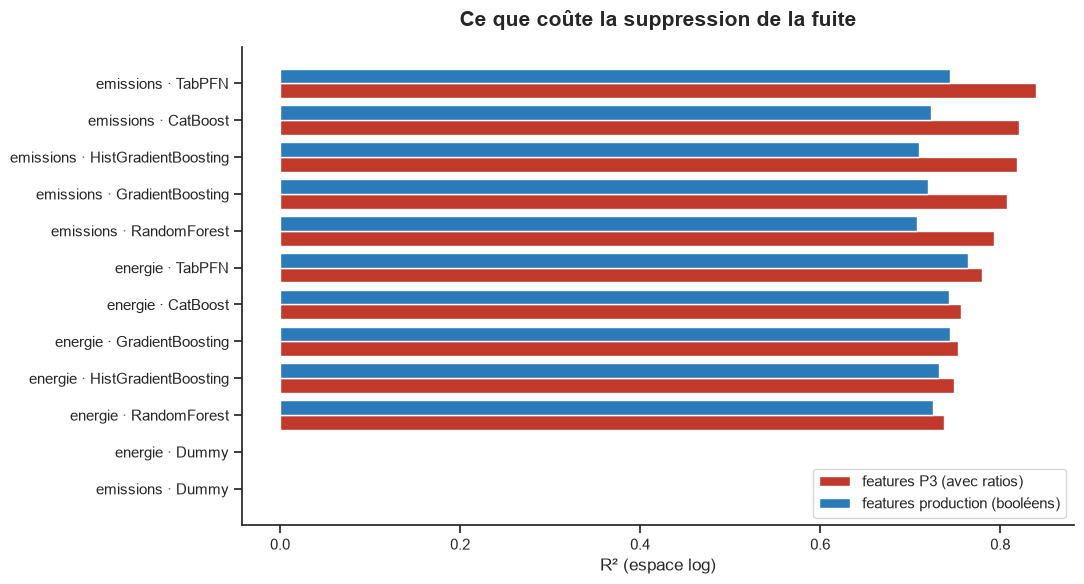

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_df = comparison.reset_index()
plot_df["label"] = plot_df["cible"] + " · " + plot_df["modele"]
plot_df = plot_df.sort_values("ratios_P3")
ypos = np.arange(len(plot_df))

ax.barh(ypos - 0.2, plot_df["ratios_P3"], height=0.4, label="features P3 (avec ratios)", color="#c0392b")
ax.barh(ypos + 0.2, plot_df["booleens"], height=0.4, label="features production (booléens)", color="#2b7bba")
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("R² (espace log)")
ax.set_title("Ce que coûte la suppression de la fuite", fontsize=15, pad=15, fontweight="bold")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

## 7. Sélection et arbitrage de déploiement

Le meilleur score ne gagne pas automatiquement. Trois critères s'ajoutent à la
performance : le poids de l'artefact à servir, le coût de l'explicabilité, et les
contraintes de licence.

**Contrainte connue d'avance** : TabPFN-3 est sous licence `tabpfn-3-license-v1.0`,
qui autorise explicitement l'évaluation et le benchmark interne mais **interdit
tout usage commercial ou en production**. Quel que soit son score, il ne peut pas
être déployé sur le Space. Il figure ici comme plafond de référence.

In [12]:
DEPLOYABLE = [m for m in MODELS if m != "TabPFN"]

selection = {}
for cible in targets:
    subset = results[(results["cible"] == cible) & (results["modele"].isin(DEPLOYABLE))]
    best = subset.loc[subset["R2_log"].idxmax()]
    ceiling = results[(results["cible"] == cible)]["R2_log"].max()
    selection[cible] = best["modele"]
    print(f"{cible:10s} -> {best['modele']:20s} R2={best['R2_log']:.4f}"
          f"   (plafond tous modèles : {ceiling:.4f})")

selection

energie    -> GradientBoosting     R2=0.7447   (plafond tous modèles : 0.7643)
emissions  -> CatBoost             R2=0.7234   (plafond tous modèles : 0.7445)


{'energie': 'GradientBoosting', 'emissions': 'CatBoost'}

## 8. Conformalisation et couverture

`CrossConformalRegressor` calcule les scores de conformité hors fold sur les 80 %
d'entraînement, puis produit des intervalles au niveau retenu (75 %, cf. plus bas). La couverture est vérifiée
sur les 20 % de test, jamais vus.

**Le modèle prédit en espace log**, l'intervalle est donc calculé en log puis
re-exponentié. La transformation étant monotone, la garantie de couverture est
préservée — l'intervalle résultant est asymétrique dans l'échelle d'origine, ce
qui est correct et devra être expliqué dans l'interface.

**Comment lire le graphique ci-dessous.** Les bâtiments sont triés par
**prédiction** — c'est le seul ordre où le ruban se lit, puisque l'intervalle est
centré sur la prédiction et non sur la vérité. La ligne foncée est la prédiction,
le ruban son intervalle de confiance, et les points sont les valeurs **réelles** : bleus
quand l'intervalle les capture, rouges quand il les rate. L'écart entre un point
et la ligne est exactement l'erreur du modèle sur ce bâtiment.

En log, la largeur est quasi constante — médiane 2,18, écart-type 0,08, soit 3,8 %
de variation. C'est le `± q` de la prédiction conforme : un même écart appliqué à
tout le monde, qui devient un **facteur multiplicatif** une fois repassé en kBtu.

**Comment lire le tableau.** La médiane et la moyenne de la cible sont rappelées
en tête pour donner l'échelle — sans elles, une largeur d'intervalle en kBtu ne
veut rien dire. La ligne `intervalle — facteur` donne la lecture multiplicative :
l'intervalle va de la prédiction divisée par ce facteur à la prédiction
multipliée par lui. La ligne `largeur / médiane cible` rapporte la largeur de
l'intervalle à la taille d'un bâtiment typique.

In [13]:
from mapie.regression import CrossConformalRegressor

UNITES = {"energie": "kBtu", "emissions": "tCO2e"}

coverage_rows = []
conformal_models = {}

for cible, model_name in selection.items():
    y = targets[cible]
    mapie = CrossConformalRegressor(
        estimator=MODELS[model_name](),
        confidence_level=CONFIDENCE,
        cv=N_SPLITS,
        method="plus",
        random_state=RANDOM_STATE,
    )
    mapie.fit_conformalize(X.loc[idx_train], y.loc[idx_train])
    conformal_models[cible] = mapie

    y_pred_log, intervals_log = mapie.predict_interval(X.loc[idx_test])
    lower_log, upper_log = intervals_log[:, 0, 0], intervals_log[:, 1, 0]
    y_true_log = y.loc[idx_test].to_numpy()

    covered = (y_true_log >= lower_log) & (y_true_log <= upper_log)
    reel = np.expm1(y_true_log)
    lower, upper = np.expm1(lower_log), np.expm1(upper_log)
    largeur = np.median(upper - lower)

    coverage_rows.append({
        "cible": cible,
        "unité": UNITES[cible],
        "modèle": model_name,
        # Scale reference, so the interval width below can be read
        "cible — médiane": np.median(reel),
        "cible — moyenne": reel.mean(),
        "couverture visée": CONFIDENCE,
        "couverture observée": covered.mean(),
        "intervalle — largeur médiane": largeur,
        # The multiplicative reading: interval = prediction divided/multiplied by this
        "intervalle — facteur": float(np.exp(np.median(upper_log - lower_log) / 2)),
        "largeur / médiane cible": largeur / np.median(reel),
        "R2 log (test)": r2_score(y_true_log, y_pred_log),
    })

pd.DataFrame(coverage_rows).set_index("cible").T

cible,energie,emissions
unité,kBtu,tCO2e
modèle,GradientBoosting,CatBoost
cible — médiane,2602213.75,48.76
cible — moyenne,8622817.492032,179.410211
couverture visée,0.75,0.75
couverture observée,0.812689,0.809668
intervalle — largeur médiane,4047005.008314,107.251655
intervalle — facteur,2.025302,2.342608
largeur / médiane cible,1.555216,2.199583
R2 log (test),0.743387,0.748059


### Le choix du niveau de confiance

Le niveau de confiance est un **paramètre produit**, pas un paramètre de modèle :
il ne modifie ni le modèle, ni son R², ni son MedAPE, et la couverture est vérifiée
et tenue à *chaque* niveau. Ce qu'il règle, c'est la quantité d'incertitude
affichée à l'utilisateur.

Le critère retenu est donc l'utilité : **à partir de quand l'intervalle cesse-t-il
d'être actionnable ?** À 90 %, il faut dire « entre le tiers et le triple », ce qui
n'aide personne à prioriser. À 75 %, le facteur tombe à 2,03 et l'intervalle se dit
en une phrase compréhensible sans formation : **« entre la moitié et le double de
l'estimation »**.

À noter, CV+ sur-couvre systématiquement : à 75 % visés, la couverture observée est
de 81 %. On annonce moins que ce qu'on délivre.

In [14]:
# Width against reliability, across confidence levels.
# Documents the product decision rather than leaving it implicit.
arbitrage = []
for niveau in [0.50, 0.60, 0.70, 0.75, 0.80, 0.90, 0.95]:
    for cible, model_name in selection.items():
        y = targets[cible]
        essai = CrossConformalRegressor(
            estimator=MODELS[model_name](), confidence_level=niveau,
            cv=N_SPLITS, method="plus", random_state=RANDOM_STATE,
        )
        essai.fit_conformalize(X.loc[idx_train], y.loc[idx_train])
        _, iv = essai.predict_interval(X.loc[idx_test])
        lo_log, hi_log = iv[:, 0, 0], iv[:, 1, 0]
        vrai = y.loc[idx_test].to_numpy()
        largeur = np.median(np.expm1(hi_log) - np.expm1(lo_log))

        arbitrage.append({
            "cible": cible,
            "niveau visé": niveau,
            "couverture observée": ((vrai >= lo_log) & (vrai <= hi_log)).mean(),
            "facteur": float(np.exp(np.median(hi_log - lo_log) / 2)),
            "largeur médiane": largeur,
            "largeur / médiane cible": largeur / np.median(np.expm1(vrai)),
        })

pd.DataFrame(arbitrage).pivot(index="niveau visé", columns="cible").round(3)

couverture observée           facteur         largeur médiane  \
cible                 emissions energie emissions energie       emissions   
niveau visé                                                                 
0.50                      0.520   0.541     1.599   1.480          55.116   
0.60                      0.637   0.677     1.803   1.644          69.428   
0.70                      0.743   0.770     2.109   1.870          92.244   
0.75                      0.810   0.813     2.343   2.025         107.252   
0.80                      0.843   0.846     2.646   2.233         127.580   
0.90                      0.915   0.912     3.613   2.976         186.840   
0.95                      0.940   0.955     4.633   3.974         247.555   

                         largeur / médiane cible          
cible            energie               emissions energie  
niveau visé                                               
0.50         2086172.861                   1.130   0.802  
0.60         2748695.161                   1.424   1.056  
0.70         3509314.728                   1.892   1.349  
0.75         4047005.008                   2.200   1.555  
0.80         4609259.106                   2.616   1.771  
0.90         6790884.650                   3.832   2.610  
0.95         9678131.499                   5.077   3.719

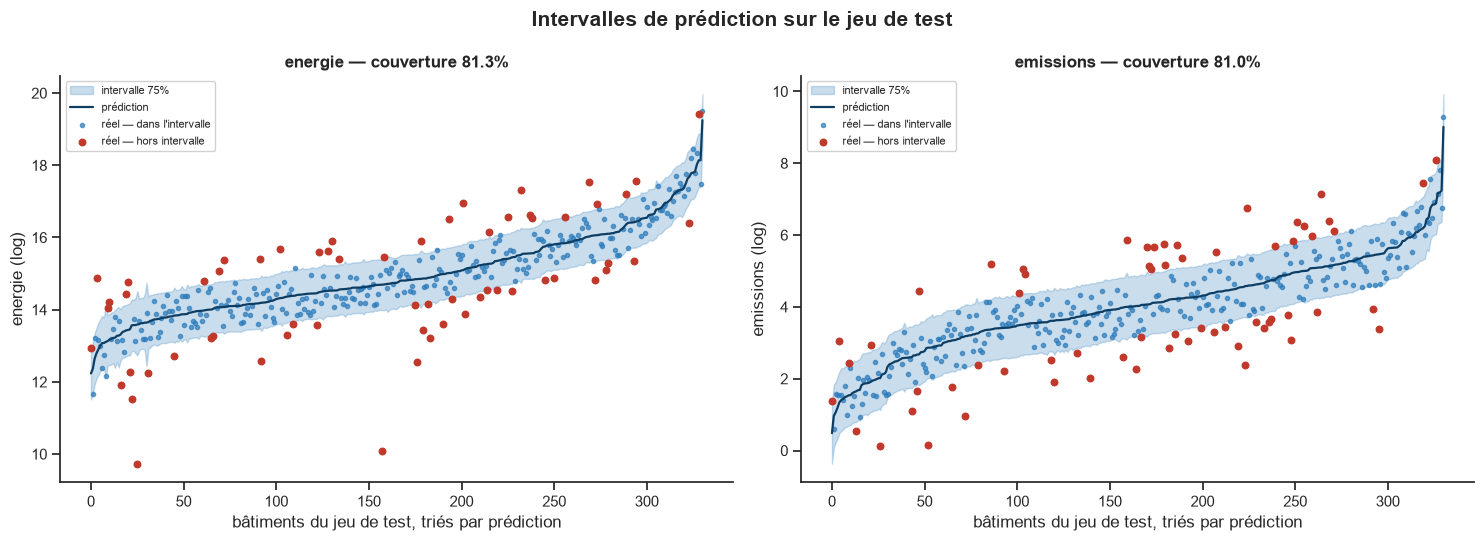

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, (cible, mapie) in zip(axes, conformal_models.items()):
    y_true_log = targets[cible].loc[idx_test].to_numpy()
    y_pred_log, intervals_log = mapie.predict_interval(X.loc[idx_test])
    lower_log, upper_log = intervals_log[:, 0, 0], intervals_log[:, 1, 0]
    covered = (y_true_log >= lower_log) & (y_true_log <= upper_log)

    # Sorting by PREDICTION, not by truth: the band is centred on the prediction,
    # so this is the only ordering where it reads as a smooth ribbon. The scatter
    # around it is then exactly the model error.
    order = np.argsort(y_pred_log)
    pos = np.arange(len(order))
    ok = covered[order]

    ax.fill_between(pos, lower_log[order], upper_log[order],
                    alpha=0.25, color="#2b7bba", label=f"intervalle {CONFIDENCE:.0%}")
    ax.plot(pos, y_pred_log[order], color="#0d3d63", linewidth=1.6, label="prédiction")
    ax.scatter(pos[ok], y_true_log[order][ok], s=9, color="#2b7bba",
               alpha=0.7, label="réel — dans l'intervalle")
    ax.scatter(pos[~ok], y_true_log[order][~ok], s=22, color="#c0392b",
               label="réel — hors intervalle")

    ax.set_xlabel("bâtiments du jeu de test, triés par prédiction")
    ax.set_ylabel(f"{cible} (log)")
    ax.set_title(f"{cible} — couverture {covered.mean():.1%}", fontweight="bold")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

fig.suptitle("Intervalles de prédiction sur le jeu de test", fontsize=15, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

**Le même résultat sur un axe linéaire.** Un axe linéaire en kBtu est
structurellement impossible ici : la borne haute vaut toujours 2,9 fois la
prédiction, donc le plafond du graphique se cale mécaniquement à trois fois le
plus gros bâtiment affiché. Même en ne gardant que la moitié du jeu, le bâtiment
médian n'occupe que 17 % de la hauteur.

La sortie est de changer de grandeur plutôt que de cadrage : on trace le **ratio
réel / prédit**. Chaque bâtiment est alors ramené à sa propre échelle, l'axe
devient linéaire, et **les 331 bâtiments tiennent dans le cadre**.

La lecture est directe : `1,0` signifie prédiction parfaite, `2,0` que le bâtiment
consomme le double de l'estimation, `0,5` la moitié. L'intervalle devient une bande
horizontale constante — entre `÷2,03` et `×2,03` — et la couverture se lit
au premier coup d'œil : c'est la proportion de points à l'intérieur de la bande.

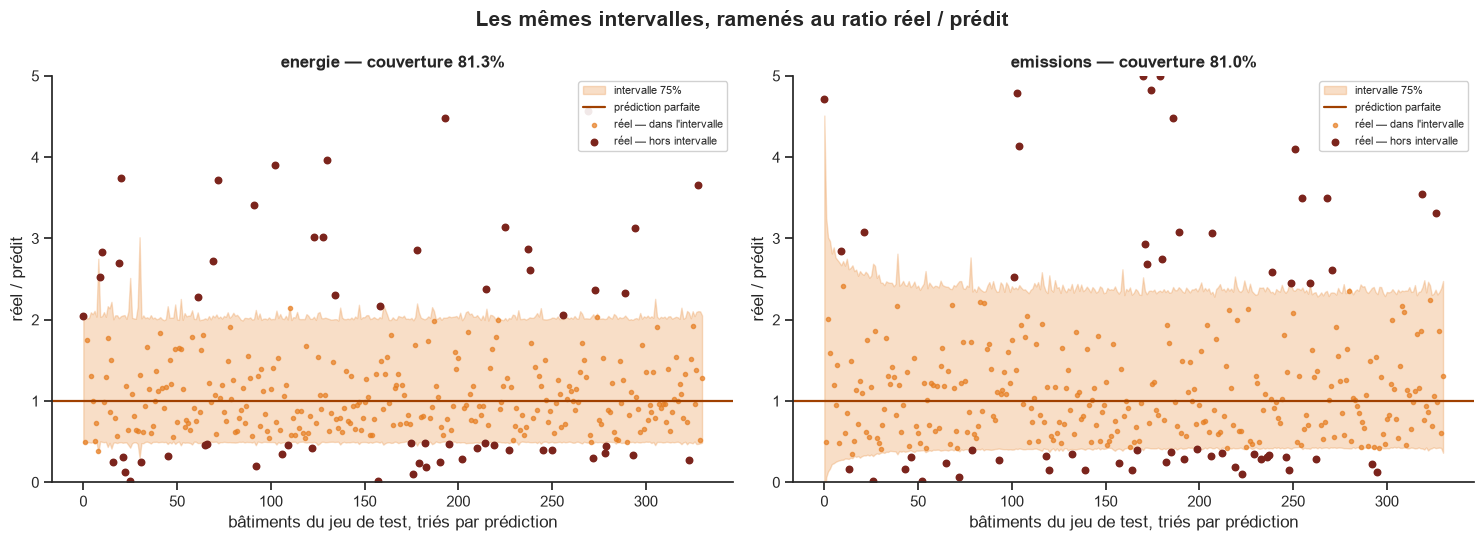

,bâtiment,prédiction (kBtu),borne basse,borne haute,largeur,facteur
0,le plus petit,2.057300e+05,1.001261e+05,4.150170e+05,3.148909e+05,2.02
1,médian,2.526643e+06,1.227255e+06,5.127134e+06,3.899880e+06,2.03
2,le plus grand,2.283098e+08,1.112488e+08,4.686138e+08,3.573650e+08,2.05


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, (cible, mapie) in zip(axes, conformal_models.items()):
    y_true = np.expm1(targets[cible].loc[idx_test].to_numpy())
    y_pred_log, intervals_log = mapie.predict_interval(X.loc[idx_test])
    y_pred = np.expm1(y_pred_log)
    lower = np.expm1(intervals_log[:, 0, 0])
    upper = np.expm1(intervals_log[:, 1, 0])
    covered = (y_true >= lower) & (y_true <= upper)

    # Everything rescaled by its own prediction: a linear axis now fits all 331
    ratio = y_true / y_pred
    order = np.argsort(y_pred)
    pos = np.arange(len(order))
    ok = covered[order]

    ax.fill_between(pos, (lower / y_pred)[order], (upper / y_pred)[order],
                    alpha=0.25, color="#e67e22", label=f"intervalle {CONFIDENCE:.0%}")
    ax.axhline(1.0, color="#a04000", linewidth=1.6, label="prédiction parfaite")
    ax.scatter(pos[ok], ratio[order][ok], s=9, color="#e67e22",
               alpha=0.7, label="réel — dans l'intervalle")
    ax.scatter(pos[~ok], ratio[order][~ok], s=22, color="#7b241c",
               label="réel — hors intervalle")

    ax.set_ylim(0, 5)
    ax.set_xlabel("bâtiments du jeu de test, triés par prédiction")
    ax.set_ylabel("réel / prédit")
    ax.set_title(f"{cible} — couverture {covered.mean():.1%}", fontweight="bold")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

fig.suptitle("Les mêmes intervalles, ramenés au ratio réel / prédit",
             fontsize=15, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

# What the interval actually means for three buildings of very different sizes
y_pred_log, intervals_log = conformal_models["energie"].predict_interval(X.loc[idx_test])
pred = np.expm1(y_pred_log)
lo, hi = np.expm1(intervals_log[:, 0, 0]), np.expm1(intervals_log[:, 1, 0])

pd.DataFrame([
    {"bâtiment": label, "prédiction (kBtu)": pred[j],
     "borne basse": lo[j], "borne haute": hi[j],
     "largeur": hi[j] - lo[j], "facteur": hi[j] / pred[j]}
    for label, j in [("le plus petit", int(np.argmin(pred))),
                     ("médian", int(np.argsort(pred)[len(pred) // 2])),
                     ("le plus grand", int(np.argmax(pred)))]
]).round(2)

## 9. Explicabilité

SHAP sur **les deux modèles retenus**, et non sur un seul : la comparaison est un
résultat en soi.

La section 6 a montré que supprimer les ratios coûte 10 points de R² sur les
émissions contre 1,5 sur l'énergie — les deux cibles ne s'appuient donc pas sur la
même information. La bivariée pointait dans la même direction (`HasSteam` corrèle
à +0,309 avec les émissions contre +0,243 avec l'énergie).

L'hypothèse à vérifier ici : **la consommation dépend surtout de la taille du
bâtiment, les émissions surtout de son mix énergétique.** À Seattle l'électricité
est hydraulique donc quasi décarbonée, tandis que le gaz et la vapeur urbaine ne
le sont pas — deux bâtiments consommant autant peuvent émettre très différemment.

Conséquence pratique pour l'interface : si les profils diffèrent, l'onglet de
prédiction devra afficher **deux waterfalls**, pas un seul.

energie    -> GradientBoosting
emissions  -> CatBoost


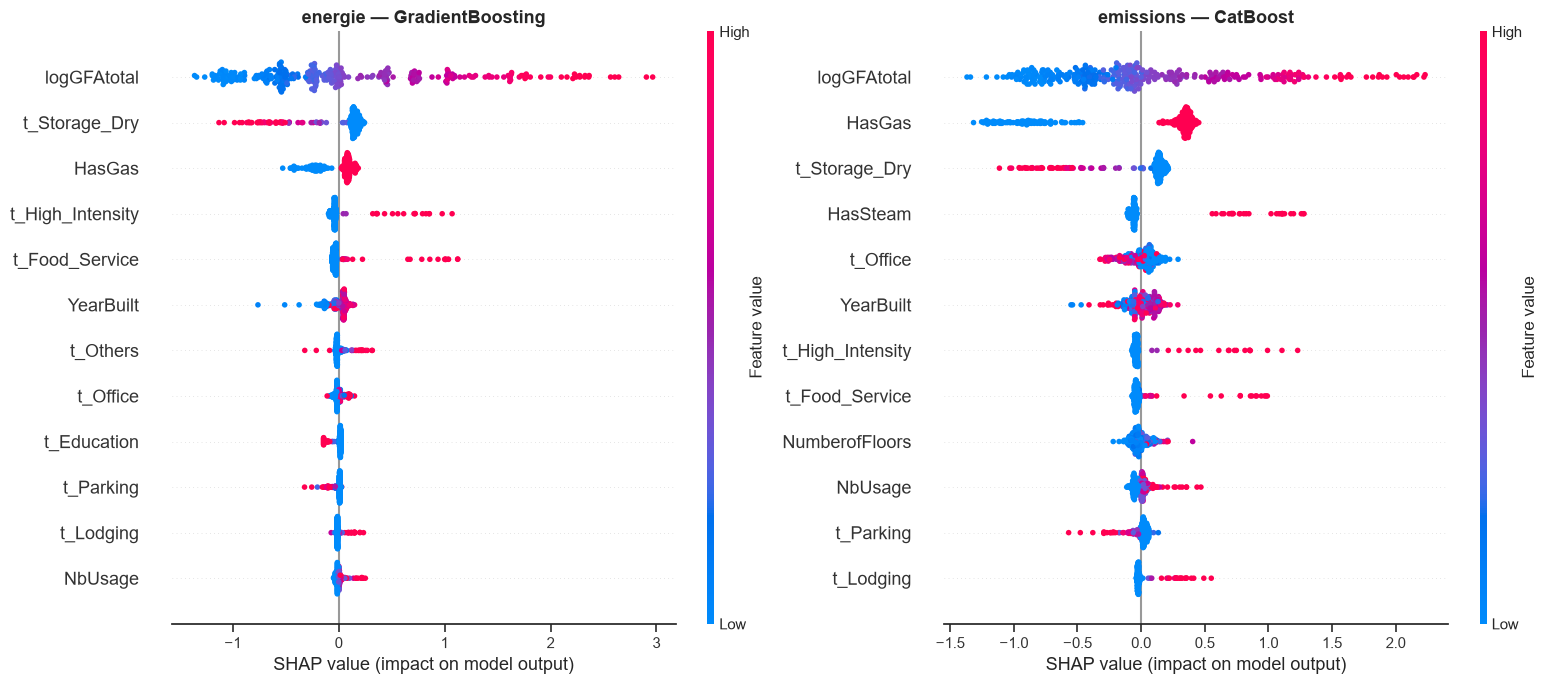

In [17]:
import shap

explanations = {}
fitted = {}

for cible, model_name in selection.items():
    model = MODELS[model_name]()
    model.fit(X.loc[idx_train], targets[cible].loc[idx_train])
    fitted[cible] = model

    explainer = shap.TreeExplainer(model)
    explanations[cible] = explainer(X.loc[idx_test])
    print(f"{cible:10s} -> {model_name}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (cible, values) in zip(axes, explanations.items()):
    plt.sca(ax)
    shap.summary_plot(values, X.loc[idx_test], max_display=12, show=False, plot_size=None)
    ax.set_title(f"{cible} — {selection[cible]}", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [18]:
# Do the two targets rely on the same variables? Mean |SHAP| ranking.
importance = pd.DataFrame({
    cible: np.abs(values.values).mean(axis=0)
    for cible, values in explanations.items()
}, index=X.columns)

# Share of total contribution, so both targets are comparable on one scale
importance = importance / importance.sum()
importance["ecart"] = importance["emissions"] - importance["energie"]
importance.sort_values("energie", ascending=False).head(15).round(4)

,energie,emissions,ecart
logGFAtotal,0.4704,0.2784,-0.1920
t_Storage_Dry,0.1447,0.1030,-0.0416
HasGas,0.0881,0.2385,0.1504
t_High_Intensity,0.0486,0.0341,-0.0144
t_Food_Service,0.0469,0.0306,-0.0163
YearBuilt,0.0400,0.0387,-0.0013
t_Others,0.0199,0.0155,-0.0044
t_Office,0.0187,0.0390,0.0203
t_Education,0.0173,0.0075,-0.0098
t_Parking,0.0140,0.0189,0.0049


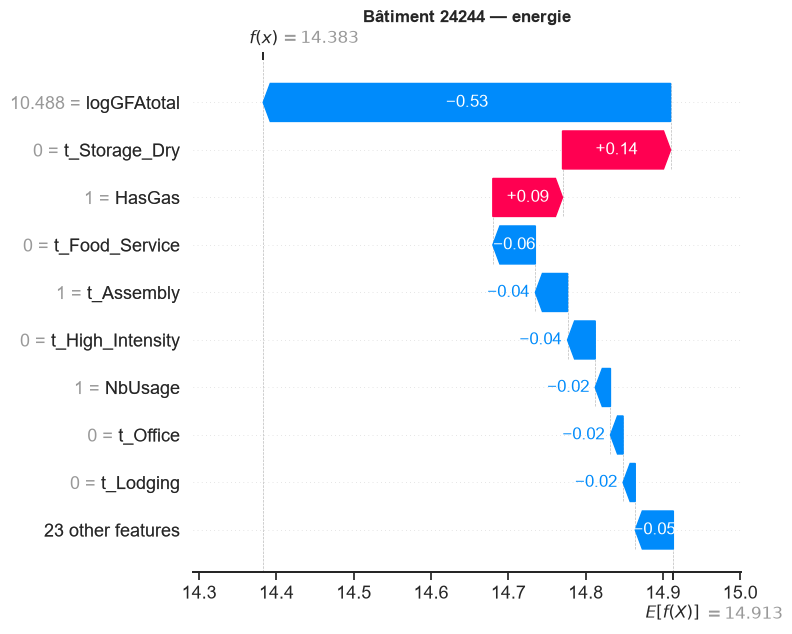

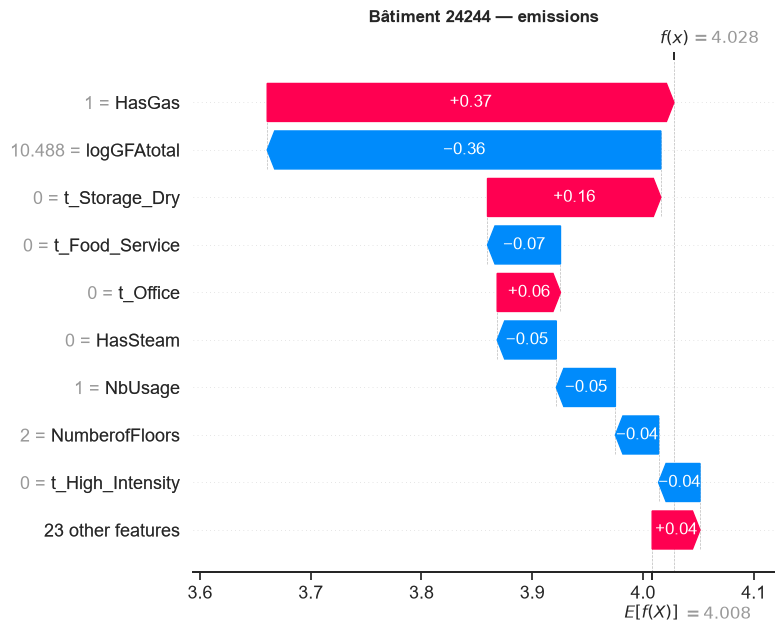

Bâtiment 24244 — réel : 1,228,114 kBtu  |  43.6 tCO2e


In [19]:
# Same building explained for both targets, as the app will show it
building = 0
building_id = desc.loc[idx_test[building], "OSEBuildingID"]

for cible, values in explanations.items():
    shap.plots.waterfall(values[building], max_display=10, show=False)
    plt.title(f"Bâtiment {building_id} — {cible}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

reel = {c: np.expm1(targets[c].loc[idx_test[building]]) for c in targets}
print(f"Bâtiment {building_id} — réel : "
      f"{reel['energie']:,.0f} kBtu  |  {reel['emissions']:,.1f} tCO2e")

## 10. Le plafond de performance

Un intervalle à ±3× peut sembler décevant. La question à trancher est donc :
**est-ce le modèle qui est médiocre, ou le problème qui est intrinsèquement
incertain ?**

Elle se mesure. On regroupe les bâtiments que le modèle voit comme
**interchangeables** — même groupe d'usage dominant, même tranche de surface — et
on regarde à quel point leur consommation réelle diffère malgré tout. Cet écart-là
est irréductible : aucun modèle utilisant ces variables ne peut le prédire.

In [20]:
# How much do buildings the model cannot tell apart actually differ?
intensite = desc["SiteEnergyUse(kBtu)"] / desc["PropertyGFATotal"]
groupe_dominant = X[list(F.USAGE_GROUPS)].idxmax(axis=1)
tranche_surface = pd.qcut(desc["PropertyGFATotal"], 5, labels=False)

comparables = pd.DataFrame({
    "groupe": groupe_dominant.to_numpy(),
    "tranche": tranche_surface.to_numpy(),
    "intensite": intensite.to_numpy(),
    "log_intensite": np.log(intensite.to_numpy()),
})

dispersion = (
    comparables.groupby(["groupe", "tranche"])
    .filter(lambda g: len(g) >= 15)
    .groupby(["groupe", "tranche"])
    .agg(
        n=("intensite", "size"),
        p10=("intensite", lambda s: s.quantile(0.10)),
        p90=("intensite", lambda s: s.quantile(0.90)),
        ecart_type_log=("log_intensite", "std"),
    )
)
dispersion["ratio_p90_p10"] = dispersion["p90"] / dispersion["p10"]
dispersion.sort_values("n", ascending=False).round(2)

n     p10     p90  ecart_type_log  ratio_p90_p10
groupe           tranche                                                    
t_Office         4        163   27.17   90.93            0.54           3.35
                 3        120   31.38  105.27            0.54           3.35
                 1         99   29.00   91.47            0.50           3.15
                 0         86   25.64   88.63            0.54           3.46
                 2         78   28.51   83.95            0.73           2.94
t_Assembly       0         70   14.61   99.74            0.86           6.83
t_Storage_Dry    1         69    9.76   71.01            0.91           7.27
                 2         69   10.06   70.02            0.77           6.96
                 0         62    7.92   63.44            0.81           8.01
t_Education      2         62   24.87   61.54            0.46           2.47
t_Storage_Dry    3         60    7.13   44.47            0.90           6.24
t_Assembly       1         41   23.24  188.40            0.84           8.11
t_Lodging        3         41   41.35  110.48            0.55           2.67
                 4         40   33.21  110.73            0.54           3.33
t_Education      3         36   30.06   58.71            0.40           1.95
t_Commercial     0         36   14.84  108.60            0.82           7.32
t_Others         1         30   20.20  150.85            1.28           7.47
t_Education      4         28   31.57   88.92            0.53           2.82
                 1         26   27.03   85.73            0.52           3.17
t_Commercial     1         26   28.48  119.06            0.86           4.18
                 3         25   35.76  145.16            0.76           4.06
                 2         25   19.15  113.82            0.73           5.95
t_Assembly       2         24   22.71  202.75            0.85           8.93
t_Lodging        2         23   32.13  114.99            0.57           3.58
t_Others         4         22   52.16  216.26            0.63           4.15
                 2         19   19.87  154.14            1.25           7.76
t_Parking        4         19   21.33  194.27            0.88           9.11
t_Storage_Dry    4         18    6.64   57.80            0.88           8.71
t_Food_Service   1         17   92.42  358.55            1.03           3.88
                 2         16  147.14  266.14            0.42           1.81
t_Others         0         16   13.91  153.09            1.00          11.01
t_High_Intensity 4         16  117.75  413.45            0.53           3.51
t_Lodging        1         15   35.16  155.60            0.65           4.43
                 0         15   28.42   82.25            0.46           2.89
t_Commercial     4         15   29.50  110.60            0.57           3.75
t_Others         3         15   29.43  150.13            0.67           5.10

In [21]:
# The irreducible spread, against what the model actually achieves
from scipy.stats import norm

sigma = dispersion["ecart_type_log"].median()
z = norm.ppf((1 + CONFIDENCE) / 2)        # follows CONFIDENCE, never hard-coded
plancher = np.exp(z * sigma)              # interval implied by that spread alone

largeurs = {}
for cible, mapie in conformal_models.items():
    _, intervals_log = mapie.predict_interval(X.loc[idx_test])
    largeurs[cible] = np.exp(np.median(intervals_log[:, 1, 0] - intervals_log[:, 0, 0]) / 2)

print(f"Ratio p90/p10 médian entre bâtiments indiscernables : {dispersion['ratio_p90_p10'].median():.2f}x")
print(f"Écart-type intra-groupe du log d'intensité          : {sigma:.3f}")
print()
print(f"Plancher irréductible ({CONFIDENCE:.0%} implicite)              : facteur {plancher:.2f}")
for cible, facteur in largeurs.items():
    print(f"Intervalle du modèle — {cible:10s}                 : facteur {facteur:.2f}")

Ratio p90/p10 médian entre bâtiments indiscernables : 4.10x
Écart-type intra-groupe du log d'intensité          : 0.699

Plancher irréductible (75% implicite)              : facteur 2.24
Intervalle du modèle — energie                    : facteur 2.03
Intervalle du modèle — emissions                  : facteur 2.34


**Le modèle est au plafond.** Son intervalle est plus serré que la dispersion
naturelle entre bâtiments indiscernables : il extrait quasiment tout le signal que
ces variables contiennent.

### Pourquoi des bâtiments identiques consomment si différemment

Parce que les features décrivent **ce qu'un bâtiment est**, alors que la
consommation dépend de **comment il est utilisé et exploité** :

- **Le taux d'occupation et les horaires.** Un plateau de bureaux à 30 %
  d'occupation contre un autre plein, ouvert 40 h ou 90 h par semaine. Facteur 2
  à lui seul.
- **Les équipements installés.** Une salle serveurs au sous-sol, une cuisine
  professionnelle, de l'imagerie médicale. Invisible dans les données, décisif
  dans la facture.
- **L'âge et le rendement des systèmes.** Une chaudière de 1975 contre une pompe
  à chaleur récente, à bâtiment identique.
- **La qualité de l'enveloppe.** Isolation, vitrages, étanchéité à l'air — deux
  immeubles de 1960 dont l'un a été rénové et l'autre non sont indiscernables
  dans ce jeu de données.
- **Les consignes et la régulation.** 19 °C ou 23 °C, réduit de nuit ou pas.

Rien de tout cela ne figure dans le benchmark de Seattle, et rien ne se déduit
d'une surface et d'une année de construction.

### Conséquence

Améliorer la précision ne passe **pas** par un meilleur algorithme — ni par TabPFN,
ni par un réglage d'hyperparamètres. Elle passe par de **nouvelles variables** :
occupation, équipements, état des systèmes, données de sous-comptage. C'est la
recommandation à porter en perspective d'évolution.

## 11. Export et enregistrement des modèles

Deux destinations, deux usages distincts.

**MLflow** garde la trace : chaque modèle retenu est enregistré dans le *model
registry* avec ses métriques, ses paramètres et sa signature. C'est ce qui rend le
choix rejouable et auditable — la matière de la section 5.2 du rapport.

**Les fichiers `joblib`** sont ce qui part réellement en production. Ils seront
poussés sur le Hub Hugging Face et chargés par le Space. Un `metadata.json` les
accompagne : versions de bibliothèques, ordre exact des variables, niveau de
confiance, métriques de référence. Sans lui, un artefact rechargé dans six mois
est un objet muet.

**Le modèle exporté est réentraîné sur la totalité des 1655 bâtiments**, pas
seulement sur les 80 % d'entraînement. C'est la pratique standard une fois le
protocole validé, et elle est ici sans danger pour la garantie conformelle :
`CrossConformalRegressor` calcule ses scores **hors fold**, donc aucun bâtiment ne
sert à la fois à entraîner et à calibrer son propre intervalle. Les métriques
rapportées restent celles mesurées sur le jeu de test, jamais vu — elles estiment
la performance attendue, elles ne décrivent pas l'artefact lui-même.

In [22]:
import importlib.metadata as metadata_lib
import json
from datetime import datetime, timezone

import joblib

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

production = {}

for cible, model_name in selection.items():
    # Refit on every available building: the protocol is validated, the
    # conformity scores stay out-of-fold, so the guarantee still holds
    final = CrossConformalRegressor(
        estimator=MODELS[model_name](),
        confidence_level=CONFIDENCE,
        cv=N_SPLITS,
        method="plus",
        random_state=RANDOM_STATE,
    )
    final.fit_conformalize(X, targets[cible])
    production[cible] = final

    chemin = MODELS_DIR / f"{cible}_model.joblib"
    joblib.dump(final, chemin, compress=3)
    print(f"{cible:10s} {model_name:20s} -> {chemin.name} "
          f"({chemin.stat().st_size / 1e6:.2f} Mo)")

energie    GradientBoosting     -> energie_model.joblib (0.26 Mo)
emissions  CatBoost             -> emissions_model.joblib (1.86 Mo)


In [23]:
# Everything a future reader -- or the Space -- needs to use these artefacts
reference = {row["cible"]: row for row in coverage_rows}
scores_oof = {row["cible"]: row for row in results.to_dict("records")
              if row["modele"] == selection[row["cible"]]}

metadata = {
    "date": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "jeu_source": "Seattle Building Energy Benchmarking 2016",
    "n_batiments_entrainement": int(len(X)),
    "confidence_level": CONFIDENCE,
    "features": list(FEATURE_COLUMNS := tuple(X.columns)),
    "cible_transformee": "log1p — appliquer expm1 aux prédictions et aux deux bornes",
    "versions": {
        paquet: metadata_lib.version(paquet)
        for paquet in ["scikit-learn", "catboost", "mapie", "numpy", "pandas", "joblib"]
    },
    "modeles": {
        cible: {
            "estimateur": selection[cible],
            "fichier": f"{cible}_model.joblib",
            "R2_log_hors_fold": round(scores_oof[cible]["R2_log"], 4),
            "MedAPE_hors_fold": round(scores_oof[cible]["MedAPE"], 4),
            "couverture_observee_test": round(reference[cible]["couverture observée"], 4),
            "facteur_intervalle": round(reference[cible]["intervalle — facteur"], 3),
        }
        for cible in selection
    },
}

chemin_meta = MODELS_DIR / "metadata.json"
chemin_meta.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(metadata, indent=2, ensure_ascii=False))

{
  "date": "2026-08-21T15:41:10+00:00",
  "jeu_source": "Seattle Building Energy Benchmarking 2016",
  "n_batiments_entrainement": 1655,
  "confidence_level": 0.75,
  "features": [
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "logGFAtotal",
    "NbUsage",
    "HasElectricity",
    "HasGas",
    "HasSteam",
    "nb_BALLARD",
    "nb_CENTRAL",
    "nb_DELRIDGE",
    "nb_DOWNTOWN",
    "nb_EAST",
    "nb_GREATER_DUWAMISH",
    "nb_LAKE_UNION",
    "nb_MAGNOLIA_QUEEN_ANNE",
    "nb_NORTH",
    "nb_NORTHEAST",
    "nb_NORTHWEST",
    "nb_SOUTHEAST",
    "nb_SOUTHWEST",
    "t_Assembly",
    "t_Commercial",
    "t_Education",
    "t_Food_Service",
    "t_High_Intensity",
    "t_Lodging",
    "t_Office",
    "t_Others",
    "t_Parking",
    "t_Public_Safety",
    "t_Storage_Dry"
  ],
  "cible_transformee": "log1p — appliquer expm1 aux prédictions et aux deux bornes",
  "versions": {
    "scikit-learn": "1.9.0",
    "catboost": "1.2.10",
    "mapie": "1.5.0",
    "numpy

In [24]:
from mlflow.models import infer_signature

# MLflow 3 serialises sklearn models with skops rather than pickle: safer, but it
# refuses any class it does not know. MAPIE and CatBoost are not in its default
# allow-list, so we declare them explicitly rather than falling back to pickle.
TRUSTED_TYPES = [
    "mapie.conformity_scores.bounds.absolute.AbsoluteConformityScore",
    "mapie.estimator.regressor.EnsembleRegressor",
    "mapie.regression.regression.CrossConformalRegressor",
    "mapie.regression.regression._MapieRegressor",
    "sklearn.model_selection._split.KFold",
    "catboost.core.CatBoostRegressor",
]

for cible, modele in production.items():
    with mlflow.start_run(run_name=f"production-{cible}"):
        mlflow.set_tags({
            "etape": "production",
            "cible": cible,
            "estimateur": selection[cible],
        })
        mlflow.log_params({
            "estimateur": selection[cible],
            "confidence_level": CONFIDENCE,
            "n_features": X.shape[1],
            "n_batiments": len(X),
        })
        mlflow.log_metrics({
            "R2_log_hors_fold": scores_oof[cible]["R2_log"],
            "MedAPE_hors_fold": scores_oof[cible]["MedAPE"],
            "couverture_test": reference[cible]["couverture observée"],
            "facteur_intervalle": reference[cible]["intervalle — facteur"],
        })

        mlflow.sklearn.log_model(
            modele,
            name=f"{cible}_conformal",
            signature=infer_signature(X, modele.predict(X.head(20))),
            input_example=X.head(3),
            registered_model_name=f"seattle-{cible}",
            skops_trusted_types=TRUSTED_TYPES,
        )
        mlflow.log_artifact(str(chemin_meta))

print("Modèles enregistrés dans le registry MLflow")

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/21 17:41:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'seattle-energie'.
Created

Modèles enregistrés dans le registry MLflow



Successfully registered model 'seattle-emissions'.
Created version '1' of model 'seattle-emissions'.


**Désigner la version déployée.** Enregistrer un modèle ne dit pas lequel est en
production. Les *stages* (`Staging`, `Production`) sont dépréciés depuis MLflow 2.9
au profit des **alias** : on pose `@champion` sur la version retenue, et le reste
du projet s'adresse à `models:/seattle-energie@champion` sans jamais coder un
numéro de version en dur. Poser un `@challenger` sur un modèle candidat permettrait
ensuite de comparer les deux sans rien débrancher.

In [25]:
from mlflow import MlflowClient

# Stages (Staging/Production) are deprecated since MLflow 2.9 — the current way to
# designate the deployed version is an alias. `models:/seattle-energie@champion`
# then always resolves to whatever is in production, without hard-coding a number.
client = MlflowClient()

for cible in production:
    nom_registre = f"seattle-{cible}"
    derniere = max(client.search_model_versions(f"name='{nom_registre}'"),
                   key=lambda v: int(v.version))

    client.set_registered_model_alias(nom_registre, "champion", derniere.version)
    client.set_model_version_tag(nom_registre, derniere.version, "cible", cible)
    client.set_model_version_tag(nom_registre, derniere.version, "estimateur", selection[cible])
    client.set_model_version_tag(nom_registre, derniere.version,
                                 "confidence_level", str(CONFIDENCE))
    client.set_model_version_tag(nom_registre, derniere.version, "features",
                                 str(X.shape[1]))

    print(f"{nom_registre:20s} version {derniere.version} -> alias @champion")

# The alias is the address the rest of the project should use
for cible in production:
    reference = client.get_model_version_by_alias(f"seattle-{cible}", "champion")
    print(f"  models:/seattle-{cible}@champion  ->  version {reference.version}")

seattle-energie      version 1 -> alias @champion
seattle-emissions    version 1 -> alias @champion
  models:/seattle-energie@champion  ->  version 1
  models:/seattle-emissions@champion  ->  version 1


In [26]:
# The artefact must survive a cold reload -- verify rather than assume
for cible in production:
    recharge = joblib.load(MODELS_DIR / f"{cible}_model.joblib")
    p_ref, i_ref = production[cible].predict_interval(X.head(50))
    p_new, i_new = recharge.predict_interval(X.head(50))
    assert np.allclose(p_ref, p_new) and np.allclose(i_ref, i_new)
    print(f"{cible:10s} rechargement vérifié — prédictions et intervalles identiques")

energie    rechargement vérifié — prédictions et intervalles identiques
emissions  rechargement vérifié — prédictions et intervalles identiques


## 12. Conclusions

*Ces conclusions alimentent les sections 2, 3 et 5 du rapport. Les décisions sont
consignées dans `docs/ecarts_vs_P3.md`.*

### Modèles retenus

| Cible | Modèle | R² (hors fold) | Plafond tous modèles |
|---|---|---|---|
| Énergie | **GradientBoosting** | 0,7447 | 0,7643 (TabPFN) |
| Émissions | **CatBoost** | 0,7234 | 0,7445 (TabPFN) |

Le `DummyRegressor` est à −0,0001 : la référence R² = 0 est bien calée, les
scores ci-dessus mesurent une vraie capacité prédictive.

### Le coût de la suppression de la fuite — résultat central de l'audit

Rejouer le protocole avec les ratios de P3 puis avec les booléens de présence
donne un écart **très asymétrique** :

| Cible | avec ratios (P3) | avec booléens | écart |
|---|---|---|---|
| Émissions | 0,808 à 0,821 | 0,707 à 0,745 | **≈ −10 points** |
| Énergie | 0,737 à 0,779 | 0,725 à 0,764 | ≈ −1,5 point |

L'explication est physique : l'électricité de Seattle est hydraulique, donc quasi
décarbonée, alors que le gaz et la vapeur urbaine ne le sont pas. Connaître
`RatioGaz` et `RatioSteam`, c'est presque *calculer* les émissions plutôt que les
prédire. La consommation totale, elle, dépend peu du mix.

**Conclusion pour le rapport : le 0,80 annoncé par P3 sur les émissions reposait
largement sur une information indisponible au moment où la prédiction est utile.**
Un modèle utilisable sur un bâtiment non relevé plafonne autour de 0,72.

La reproduction de la baseline valide la démarche : GradientBoosting avec les
ratios atteint 0,808 sur les émissions, contre 0,80 rapporté par P3.

### TabPFN : plafond de référence, non déployé

TabPFN devance les modèles retenus de 2,0 et 2,1 points sans le moindre réglage.
Il n'est pas retenu, pour trois raisons cumulatives :

1. **Licence.** `tabpfn-3-license-v1.0` autorise l'évaluation et le benchmark
   interne, mais interdit tout usage commercial ou en production.
2. **Coût de calcul.** 40 s contre 0,5 s pour GradientBoosting, soit un facteur 80.
3. **Significativité.** L'écart-type du R² d'un split à l'autre est de 0,025 à
   0,032, mesuré sur 8 tirages. L'avantage de 0,02 de TabPFN est **du même ordre
   que le bruit d'échantillonnage** — il n'est pas solidement établi.

Autrement dit : un modèle sous licence restrictive, 80 fois plus coûteux, pour un
gain qui ne se distingue pas du bruit.

### Ce que le modèle vaut réellement

Les métriques absolues sont trompeuses sur cette cible : **cinq bâtiments sur 331
portent 85 % de la RMSE au carré**, un seul en porte 76 %. La RMSE ne mesure pas
le modèle, elle mesure un campus universitaire de 9,3 M sq ft.

La lecture honnête est relative et robuste — **le bâtiment typique est estimé à
environ ±35 % sur l'énergie**. C'est suffisant pour classer un parc et prioriser
des audits ; ce ne l'est pas pour facturer.

Distribution de l'erreur relative : p50 ≈ 35 %, p75 ≈ 63 %, **p90 ≈ 100 %**. Un
bâtiment sur dix est faux d'un facteur 2 — ce qu'une estimation ponctuelle
masquerait entièrement, et qui justifie les intervalles.

### Intervalles de prédiction

| | Énergie (kBtu) | Émissions (tCO2e) |
|---|---|---|
| Cible — médiane | 2 602 214 | 48,8 |
| Cible — moyenne | 8 622 818 | 179,4 |
| Couverture visée | 75 % | 75 % |
| **Couverture observée** | **81,3 %** | **81,0 %** |
| Intervalle — largeur médiane | 4 047 005 | 107,3 |
| **Intervalle — facteur** | **÷ et × 2,03** | **÷ et × 2,34** |
| Largeur / médiane de la cible | 1,6 | 2,2 |

**Le niveau de confiance a été fixé à 75 %**, et c'est une décision produit : il ne
modifie ni le modèle ni ses métriques, et la couverture est vérifiée à chaque
niveau. À 90 %, l'intervalle valait un facteur 2,98 — « entre le tiers et le
triple », inexploitable pour prioriser. À 75 %, il tombe à **2,03**, soit « entre
la moitié et le double de l'estimation » : une phrase compréhensible sans
formation. Le tableau d'arbitrage complet figure en section 8.

On annonce par ailleurs moins que ce qu'on délivre — 75 % visés, **81 % observés**,
CV+ sur-couvrant systématiquement.

La médiane et la moyenne de la cible sont rappelées parce qu'une largeur en kBtu
ne se lit pas sans échelle. L'écart entre les deux (2,6 M contre 8,6 M) rappelle
au passage combien la distribution est tirée par les géants.

**Les émissions sont plus incertaines que l'énergie** : facteur 2,34 contre 2,03.
Cohérent avec le reste — c'est aussi la cible qui perdait le plus au retrait des
ratios (−10 points de R²), parce qu'elle dépend d'une information sur le mix
énergétique que les booléens ne capturent qu'en partie.

La couverture est légèrement supérieure à la cible, comportement attendu de CV+
dont la garantie est ≥ 1−α. À assumer tel quel dans l'interface : l'intervalle est
large parce que l'incertitude est réelle, pas parce que la méthode échoue.
Rappel : la garantie est **marginale**, pas conditionnelle — 75 % en moyenne, pas
75 % par type de bâtiment.

### Ce que les deux modèles regardent

Part de contribution SHAP, normalisée :

| Variable | Énergie | Émissions |
|---|---|---|
| `logGFAtotal` | **47,0 %** | 27,8 % |
| `HasGas` | 8,8 % | **23,9 %** |
| `t_Storage_Dry` | 14,5 % | 10,3 % |

**La consommation est une affaire de taille, les émissions une affaire de
combustible.** Le modèle a retrouvé seul la spécificité du réseau électrique de
Seattle. Cela valide *a posteriori* le remplacement des ratios par les booléens :
`HasGas` capte l'essentiel de ce que portait `RatioGaz`, tout en restant
renseignable par un utilisateur.

Nuance de lecture : `HasSteam` n'apparaît pas en tête malgré une corrélation de
+0,309 avec les émissions. Seuls 114 bâtiments sur 1655 ont la vapeur, donc sa
contribution moyennée sur la population est diluée — elle reste décisive pour ces
114 bâtiments.

### Empreinte carbone

*À compléter après exécution : le tableau comparatif donne `co2_g` par modèle et
la colonne `g_CO2_par_point_R2`. Vu le facteur 80 sur les temps de calcul, on
s'attend à ce que le modèle retenu soit aussi le plus sobre par point de
performance — argument à vérifier avant de l'écrire.*


### Le plafond de performance — le résultat à mettre en avant

Un intervalle à ±3× peut passer pour un aveu de faiblesse. La mesure dit le
contraire.

En regroupant les bâtiments **indiscernables pour le modèle** — même usage
dominant, même tranche de surface — leur consommation réelle varie d'un facteur
**4,10** en médiane. 163 immeubles de bureaux de taille comparable consomment
entre 27 et 91 kBtu par pied carré, et aucune variable disponible ne les
départage. L'écart-type intra-groupe du log d'intensité est de 0,699, ce qui
impliquerait à lui seul un intervalle au même niveau de confiance d'un facteur
**2,24**.

Le modèle produit **2,03**. **Il est plus serré que la dispersion naturelle entre
bâtiments indiscernables** — il extrait quasiment tout le signal que ces variables
contiennent.

La raison est structurelle : les features décrivent **ce qu'un bâtiment est**,
alors que la consommation dépend de **comment il est utilisé et exploité** —
occupation et horaires, équipements installés, rendement des systèmes, qualité de
l'enveloppe, consignes de régulation. Rien de cela ne figure dans le benchmark de
Seattle.

**Conséquence pour les perspectives** : la marge de progression n'est pas dans
l'algorithme — six familles de modèles se tiennent en 4 points de R², et TabPFN
n'en gagne que 2, dans le bruit. Elle est dans les **données** : occupation,
inventaire des équipements, âge des systèmes, sous-comptage.

Détail complet et reproductible en section 10, et dans `docs/plafond_de_performance.md`.

### Limites assumées

- Modèle calibré sur Seattle 2016 : hors de ce périmètre géographique et
  climatique, l'hypothèse d'échangeabilité tombe et la garantie de couverture avec.
- Pour les 150 bâtiments (9,1 %) déclarant plus de trois usages, la composition
  d'entraînement est calculée sur une répartition tronquée.
- Le modèle est légèrement meilleur sur les bâtiments à déclaration fiable
  (R² 0,760 contre 0,746 sur l'ensemble).
- Un bâtiment sans aucune répartition d'usage est hors domaine et refusé.